# Конспект по машинному обучению

## Введение
- Математика: градиент, методы оптимизации
- Теория вероятностей и математическая статистика: распределения, статистическая значимость, выборка
- Глубокое погружение в методы оптимизации, метод максимизации правдоподобия
- Python: алгоритмы и структуры данных, LeetCode
- Линейная регрессия, логистическая регрессия, градиентный бустинг, деревья решений, случайный лес, метрики качества и т.д.
- Проекты на Kaggle

# Лекция 1

## Основные понятия

### Модель
Функция, отображающая объекты в целевые переменные (предсказания, ответы, targets).

### Обучающая выборка
Набор примеров вида «объект – целевая переменная»:
$$
X = \{(x_i, y_i)\}, \quad i = 1, \dots, l
$$

### Признак (feature)
Некоторая характеристика объекта.

## Виды признаков
1. **Бинарные** – принимают два значения (0/1, да/нет).
2. **Числовые** – вещественные числа.
3. **Категориальные (номинальные)** – неупорядоченное множество значений.
4. **Порядковые** – частично упорядоченное множество (можно сравнивать, но арифметика неприменима, например, тип альбома).
5. **Set-valued** – набор категорий.
6. **Со сложной структурой** – звук, изображение и т.п.

Объект описывается вектором признаков:


## Постановка задачи

### Обучение с учителем
Обучающая выборка содержит правильные ответы.

- **Регрессия** – ответ – вещественное число (например, спрос на товар, продолжительность поездки).
- **Бинарная классификация** – ответ – 0 или 1.
- **Многоклассовая классификация (multiclass)** – конечное множество ответов, принадлежность к одному из классов.
- **Многоклассовая классификация с пересекающимися классами (multilabel)** – принадлежность к нескольким классам одновременно.
- **Ранжирование** – ответ – конечное упорядоченное множество.

### Обучение без учителя
- **Кластеризация** – группировка объектов без целевой переменной.
- **Понижение размерности** – уменьшение числа признаков.

## Метрики качества

1. **Бизнес-метрики** – например, будущий доход сервиса. Их трудно измерить в моменте, они зависят от совокупности всех усилий, не только машинного обучения.

2. **Онлайн (online) метрики** – характеристики работающей системы, по которым мы надеемся оценить влияние на бизнес-метрики.
   Примеры:
   - Медианная длина сессии в онлайн-игре (предполагаем, что долгая сессия — признак довольного пользователя).
   - Среднее количество бананов на полках во всех магазинах в конце дня.

3. **Оценка специально нанятыми людьми (асессорами)** – например, качество машинного перевода или релевантность выдачи в поисковой системе.

4. **Офлайн (offline) метрики** – измеряются до введения модели в эксплуатацию по историческим данным.
   В задачах предсказания таргета обычно оценивают отклонение предсказаний модели от истинных значений:
   - точность (доля верно угаданных значений),
   - среднеквадратичное отклонение.

## Функция потерь и функционал ошибки

- **Функция потерь** – положительное число, описывающее правильность ответа на одном объекте.
- **Функционал ошибки** – функция, принимающая модель и усредняющая потери по всем объектам обучающей выборки.

# Лекция 2

# Линейная регрессия

Модель линейной регрессии имеет вид:
$$
a(x) = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_d x_d
$$
где $w_i$ – веса (коэффициенты), $w_0$ – свободный член (bias).
Если положить $x_0 = 1$, то можно записать как скалярное произведение:
$$
a(x) = \sum_{i=0}^{d} w_i x_i = \mathbf{w}^\top \mathbf{x}
$$

**Используется если** признаки независимо влияют на ответ, и изменение одного признака не влияет на другие.

### One‑hot кодирование категориальных признаков

Пусть $C = \{c_1, c_2, \dots, c_n\}$ – множество значений категориального признака.
Вводятся новые бинарные признаки $b_1(x), \dots, b_n(x)$:
$$
b_j(x) = [x_i = c_j]
$$
При этом:
$$
b_1(x) + b_2(x) + \dots + b_n(x) = 1
$$
Модель становится:
$$
a(x) = w_0 + w_1 [x_1 = c_1] + w_2 [x_1 = c_2] + \dots + w_n [x_1 = c_n] + \dots
$$
То есть каждая категория вносит свой уникальный вклад в прогноз.

### Бинаризация числовых признаков

Разбиваем множество значений признака на отрезки с порогами $t_1, \dots, t_n$, где $t_0 = -\infty$, $t_{n+1} = +\infty$.
Вводятся признаки:
$$
B_i(x) = [t_{i-1} \le x_i < t_i]
$$

**Важно:** Для линейных моделей признаки нужно готовить так, чтобы модель имела смысл (например, масштабирование, кодирование).

## Измерение ошибки в регрессии

Пусть $y$ – фактическое значение, $z$ – прогноз модели.

### 1. Средняя квадратичная ошибка (MSE)
$$
L(y, z) = (y - z)^2
$$
$$
MSE(a, X) = \frac{1}{l} \sum_{i=1}^{l} (y_i - a(x_i))^2
$$

### 2. Корень из средней квадратичной ошибки (RMSE)
$$
RMSE(a, X) = \sqrt{MSE(a, X)}
$$

### 3. Коэффициент детерминации ($R^2$)
$$
R^2(a, X) = 1 - \frac{\sum_{i=1}^{l} (y_i - a(x_i))^2}{\sum_{i=1}^{l} (y_i - \bar{y})^2}
$$
где $\bar{y}$ – среднее значение целевой переменной.

### 4. Средняя абсолютная ошибка (MAE)
$$
MAE(a, X) = \frac{1}{l} \sum_{i=1}^{l} |y_i - a(x_i)|
$$

### 5. Функция Хубера
Комбинирует MSE в окрестности нуля и MAE на больших расстояниях.

### 6. Несимметричные функции потерь
Например, для модели, рекомендующей цену на квартиру, штраф за недопрогноз должен быть больше, чем за перепрогноз.

### 7. MSLE (Mean Squared Logarithmic Error)
$$
MSLE = \frac{1}{l} \sum_{i=1}^{l} (\log(1 + y_i) - \log(1 + a(x_i)))^2
$$

### 8. MAPE (Mean Absolute Percentage Error)
$$
MAPE = \frac{1}{l} \sum_{i=1}^{l} \left| \frac{y_i - a(x_i)}{y_i} \right| \cdot 100\%
$$

## Матричное представление линейной регрессии

### 1. Матрица объекты-признаки ($X$)
Строки матрицы соответствуют объектам, столбцы — признакам.  
Пусть у нас $l$ объектов и $d$ признаков. Тогда:

$$
X = \begin{pmatrix}
x_{11} & x_{12} & \cdots & x_{1d} \\
x_{21} & x_{22} & \cdots & x_{2d} \\
\vdots & \vdots & \ddots & \vdots \\
x_{l1} & x_{l2} & \cdots & x_{ld}
\end{pmatrix}
\in \mathbb{R}^{l \times d}
$$

### 2. Вектор весов ($w$)
Вектор коэффициентов модели (включая свободный член, если добавлен столбец из единиц):

$$
w = \begin{pmatrix} w_0 \\ w_1 \\ \vdots \\ w_d \end{pmatrix} \in \mathbb{R}^{d}
$$

### 3. Вектор ответов ($y$)
Истинные значения целевой переменной для каждого объекта:

$$
y = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_l \end{pmatrix} \in \mathbb{R}^{l}
$$

### 4. Предсказания модели ($\hat{y}$)
Вектор предсказаний вычисляется как произведение матрицы признаков на вектор весов:

$$
\hat{y} = X w
$$

### 5. Вектор ошибок ($e$)
Разница между истинными значениями и предсказаниями:

$$
e = y - \hat{y} = \begin{pmatrix} y_1 - \hat{y}_1 \\ y_2 - \hat{y}_2 \\ \vdots \\ y_l - \hat{y}_l \end{pmatrix}
$$

### 6. Среднеквадратичная ошибка (MSE) через евклидову норму
MSE — это средний квадрат ошибок:

$$
MSE = \frac{1}{l} \sum_{i=1}^{l} e_i^2
$$

Используя **евклидову норму** вектора ошибок $\|e\|$, можно записать компактно:

$$
MSE = \frac{1}{l} \|e\|^2 = \frac{1}{l} \sum_{i=1}^{l} e_i^2
$$

где $\|e\| = \sqrt{\sum_{i=1}^{l} e_i^2}$ — евклидова норма вектора ошибок.
# Решение задачи машинного обучения
Мы ищем минимум MSE => сичтаем градиент и ищем решение    

$W = (X^\top X)^{-1} X^\top y$  
Применяется редко, так как операция поиска обратной матрицы кубическая  
**Весь способ работает только для  MSE**

# Лекция 3

### Борьба с переобучением линеной модели   
1. **Регуляризация** - запрет на большие по модулю веса

$$
Q(\beta) = \mathcal{L}(\beta) + \lambda \|\beta\|_2^2
$$

где  
$$
\|\beta\|_2^2 = \sum_{j} \beta_j^2
$$  
Q - регуляризованный функционал  
$ \|\beta\|_2^2$ - регуляризатор  
$\lambda >= 0$ - коэффициент регуляризации  
**Решение в случае MSE**  
$W = (X^\top X + \lambda I)^{-1} X^\top y$  
I - единичная => гарантированно можно посчитать решение не обращая внимания на вырожденность матрицы  
**В регуляризатор не входит свободный коэффициент!!!** иначе а(х) не сможет быть одного порядка с целевой переменной  

### Почему большие веса это плохо?  
При маленьком изменении признаков предсказание сильно меняется

### Как выбирать лямбду?  
**По обучающей выборке** выбираем ту при которой ошибка минимальна(плохо, т.к. оптимально $\lambda = 0$)  
**Гиперпараметр** - нельзя подбирать по выборке и вводятся для улучшения качества на новых данных  
нужно подбирать по кросс валидации или отлженной выборке

### Почему еще надо регуляризовать? 
**Допустим в Х есть линейно зависимые признаки** - существект вектор **v**, такой что для любого вектора признаков **x** из выборки выполняется **<v,x>** = 0
Допустим мы нашли W* - лучшие по MSE веса  
<W* +av,x> = <W*,x> + a<v,x> = <W*,x> следовательно решение задачи ML не единственное  
W*+av - тоже решения и если увеличить альфа до бесконечности, то будет переобученная модель


## Обучение линейной регрессии  
### для MSE: $W = (X^\top X)^{-1} X^\top y$
- слишком дорогая операция обращения  
### Градиентное обучение моделей(gradient descend или GD)  
Так как нам надо найти минимум функции, то хорошим решением будет опускаться до минимума(как со спуском по горе)  
$W^{(0)}$ - **начальное приближение**  
$\nabla_wQ(w)$ - **градиент Q** по w(минус градиент это сторона наискорейшего убывания)  
$\zeta$ - **длина шага(learning rate)**
$$ 
W^{(k)} = W^{(k-1)} - \zeta_k\nabla_wQ(w^{(k-1)}) - шаг\:градиентного\:спуска
$$  
#### Момент остановки спуска
 - Когда ошибка на тестовой выборке перестает уменьшаться
 - Если разность норм k и k-1 векторов мала
 - Если разность ошибок для веторов весов на k и k-1 шагах мала  
  
# Улучшения  
$q_i$ - ошибка на конкретном обьекте
# - Менять градиент на его оценки  
$Q(w, X) = \frac{1}{l} \sum_{i=1}^{l} (<w_i,x_i> - y_i)^2$  
почти всегда функционалы это сумма каких-то функций  
$Q(w, X) = \frac{1}{l} \sum_{i=1}^{l} q_i(w)$  
Тогда нужно считать очень много градиентов
$$
\nabla_wQ(w,X) = \frac{1}{l} \sum_{i=1}^{l} \nabla_wq_i(w)
$$  
это полный градиент  
Не обязательно считать точный градиент, поэтому попробуем заменить среднее на что-то попроще  
### - Стoхастический градиентный спуск(SGD):  
$$
\nabla_wQ(w)\:заменяем\:на\:\nabla_wq(w)\:-градиент\:случайной\:функции
$$

получается на каждом шаге минимизируется ошибка на одном обьекте, что не очень хорошо  
чтобы гарантировать сходимость к минимуму надо чтобы ряд длин шагов расходился, а ряд квадратов длин шагов сходился(они достаточно большие, но не слишком)  
Обычно берут  
$$
\zeta = \lambda (\frac{s_{0}}{s_{0} + u})^p
$$  
где $\lambda$, p, $s_{0}$ - параметры  
### если функционал выпуклый, гладкий, имеет минимум, то в полном функционала значение функционала в точке с к-ого шага минус значенив в точке оптимума убывает как О от 1\к  
$$
FMGD:
Q(w^{k}) - Q(w_{x}) = \underline{O}(\frac{1}{k})
$$  
### А в стахастическом на порядок меньше(сойдется быстрее)
$$
SGD:
Q(w^{k}) - Q(w_{x}) = \underline{O}(\frac{1}{\sqrt{k}})
$$  
### Mini-batch GD   
### чтобы не оценивать по одной точке оцениваем градиент полного функционала средним градиентом по n объектам  


### Метод SAG(stacastic average gradient)  
Когда находим приближение считаем градиенты по всем слагаемым функционала  
$$
z_{i}^{(0)} = \nabla q_i(w^{(0)})
$$
на k-ой итерации обновляем градиент только для одного обЪекта, а для остальных переношу с предыдущего шага(харним все градиенты, а обновляем по одному на шаг):
$$  
z^{(k)}_{i} = \begin{cases}  
\nabla_wq_i(w^{(k-1)}), i = i_{k} \\   
z_{i}^{(k-1)}, иначе   
\end{cases}
$$
Тогда оценка градиента на $w^{(k-1)}$ наборе весов оценивается как  
$$
\frac{1}{l} \sum_{i=1}^{\ell} z_i^{k}
$$
скорость сходимости как у полного градиента, можно не хранить все градиенты, просто храня сумму и меняя одно слагаемое  
на практике минибатч лучше


# Изменение шага спуска  
Веса на к-ом шаге равны весам на прошлом шаге минус ошибка на длину шага  
1) Когда линни уровня вытянуты сходимость долгая из-за асцелляции  
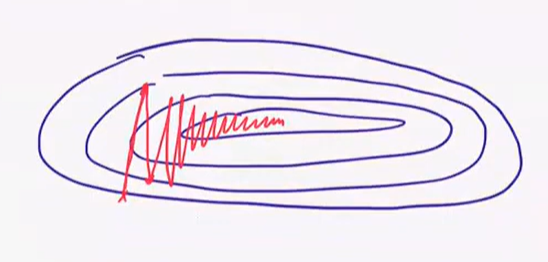  
Нужно устранить движение по у и схоранить движение по х  
Очевидно нужно их просуммировать
## Метод имупльса(momentum)  
$h_0$ = 0  
$h_k = \alpha h_{k-1}+\zeta_{k} \nabla Q(w^{(k-1)})$ где альфа фиксированно (0,1)  
$w^{(k)} = w^{(k-1)} -h_k$  
В h копим все градиенты с затуханием и шагаем в торону усредненного градиента  
2) Имеется разреженный признак  
$x_j$ - почти всегда 0  
$a(x) = ... + w_jx_j + ...$
Так как $x_j$ равно нулю, то его производная по функционалу тоже 0 и на большинствк итераций стохастического спуска вес не меняется  
Очевидно нужно менять такие приизнаки  
## Метод AdaGrad - адаптивный градиент
k - номер итерации, j - номер признака  
$G_{kj} = G_{(k-1),j} + (\nabla Q(w^{(k-1)}))^2_j$ - как сильно мы обучили вес w_j(слагаемое это вклад предыдущего шага)  
$w_j^k = w_j^{(k=1)}- \frac{\zeta_{k}}{\sqrt{G_kj+\epsilon}}(\nabla_{w} Q(w^{(k-1)}))_j$ - если меняем редко коэффициент убывает медленно  
$\epsilon$ нужен чтобы знаменатель не был 0   
НО $G_{kj}$ только растет, поэтому убывание может быть слишком быстрым  
## RMS Prop  
Почти адаград  
$G_{kj} = \alpha G_{(k-1),j} + (1-\alpha)(\nabla_{w} Q(w^{(k-1)}))_j^2$  
## Метод ADAM совмещает эти 2 идеи  

# Разреженные модели  
$Q(w,X) + \lambda \|w\|_1 \to \min_w, \quad \|w\|_1 = \sum_{j} |w_j|$  
Если увеличивать лямбду то будут появляться нулевые веса(модель разрежевается)  
Зачем?:
- ускорение  
- не все признаки полезные  
- $\ell$ < $\alpha$  

Почему?  
$0<\delta<\epsilon<1$
$w = (1, \epsilon)$   
$\|w - (\delta,0)\|_2^2= 1- 2 \delta + \delta^2 + \epsilon^2 $ изменяем первую координату на дельту и смотрим на сколько поменяестя норма    
$\|w - (\delta,0)\|_1= 1- 2 \delta + \epsilon $ изменение в L2  
  
$\|w - (0,\delta)\|_2^2= 1- 2 \epsilon \delta + \delta^2 + \epsilon^2 $ изменяем вторую координату на дельту   
$\|w - (0,\delta)\|_1= 1- 2 \delta + \epsilon $ изменение в L2  
L2 при уменьшении большого веса сильнее уменьшает штраф, поэтому ему выгоднее уменьшать большие веса и поэтому оно не занулит вес  
Проксимальные методы  

$S_{\xi\alpha}(w_i) = 
\begin{cases} 
w_i - \xi\alpha, & w_i > \xi\alpha \\
0, & |w_i| \leq \xi\alpha \\
w_i + \xi\alpha, & w_i < -\xi\alpha
\end{cases}$  
$w^{(k)} = S_{\xi\alpha}(w^{(k-1)} - \xi \nabla Q(w^{(k-1)}))$  
Делаем обычный шаг GD,применяяя оператор который прибивает координаты к нулю, а если координата уже небольшая, то меняет на 0  



# Лекция 4

# Линейная классификация  
$X = R^d$ - выборка  
$Y = {-1,+1}$ - объекты бинарные, отрицательные или положительные  
$a(x) = sign(<w,x>+ w_0)$ - линейный классификатор  
уравнение $<w,x>+w_0 = 0$ - гиперплоскость, где w - нормаль  
соответственно смотрим в какой полуплоскости ответ и назначаем знак      
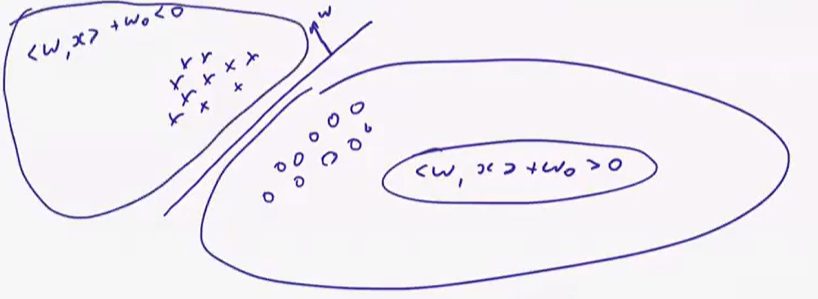   
большие требования к линейной разделимости выборки  
## Как обучать?  
$Q(a,X) = \frac{1}{\ell} \sum_{i=1}^{\ell} [a(x_i) \ne y_i] \to min$ - функционал ошибки называется доля ошибки (error rate)  
$\frac{1}{\ell} \sum_{i=1}^{\ell} [sign(<w,x_i>) \ne y_t]$  
непонятно как дифференциировать сигнум и индикатор, нужны эвристики  
Запишем функционал иначе  
$\frac{1}{\ell} \sum_{i=1}^{\ell} [y_i<w,x_i> < 0] \to min$  
$y_i<w,x_i> < 0$ => один знак у ответа и в выборке, инчае разные знаки и ответ неверный  
$M_i = y_i<w,x_i>$ - отступ(margine)  
$|M_i|$ - масштабированное расстояние от ответа до разделющей гиперплоскости  
Если значение маленькое, то прогноз неустойчив так как елси положение гиперплоскости поменяется прогноз может стать неверным  
$|M_i|$ говорит об уверенности прогноза  
$M_i<<0$ - обычно у выбросов так как модель очень уверена в неправильном ответе => что-то не так с объектом  

Функция потерь L(m) = \[M<0\](пороговая) $\leq\~{L}(M)$(гладкая)  
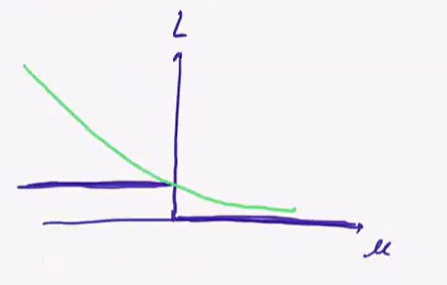  
Слева штрафует, справа нет, очевидно GD никуда не поедет, будем использовать верхнюю оценку для обучения(зеленая)  
функционал $\leq \frac{1}{\ell} \sum_{i=1}^{\ell} \~{L}(y_i<w,x_i>) \to min$  
$\~{L}(M) = log(1+e^{-M})$ - логистическая ф-я потерь  
$\~{L}(M) = max(0,1-M)$ - кусочно-линейная ф-я потерь, метод SVM(support vector machine, метод опорных векторов)  
Оптимизируем с помощью GD  




# Метрики качества(функции которые нужно максимизировать) классификации  
1) Доля верных ответов НЕ ТОЧНОСТЬ!!!!!!!!    
$accuracy(a,X) = \frac{1}{\ell} \sum_{i=1}^{\ell} [a(x_i) = y_i]$  
пример  
y = -1 :950 - здоровые люди  
y = 1 : 50 - больные люди 
Но если мы сделаем модель которая всегла выдаёт -1, то accuracy = 0.95 
Это плохо потому что  
- разные цены ошибок  
- в тестовой выборке баланс классов может меняться  
если размер классов сильно отличается то нужно насторожиться  
